# Exploratory Data Analysis (EDA)

Notebook ini bertujuan untuk melakukan eksplorasi awal terhadap dataset hasil data preparation sebelum digunakan pada tahap pemodelan machine learning.

Analisis dilakukan untuk memahami karakteristik dataset dari sisi statistik, temporal, spasial, serta hubungan antar variabel. Tahapan eksplorasi meliputi pemeriksaan struktur dataset, distribusi variabel, pola musiman, variasi spasial, hubungan korelasi antar fitur, serta evaluasi kualitas data.

Analisis ini digunakan sebagai dasar dalam menentukan karakteristik data, memilih fitur yang relevan, dan memahami pola Global Horizontal Irradiance (GHI) sebagai variabel target prediksi.

#### Konfigurasi Awal

Tahap ini menyiapkan lingkungan kerja untuk proses exploratory data analysis. Konfigurasi meliputi import library, pemuatan dataset hasil data preparation, pendefinisian target dan fitur penelitian, serta parameter yang digunakan selama proses visualisasi dan analisis data.

In [1]:
# Import library dan konfigurasi visualisasi

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


# Tentukan lokasi dataset dan muat data hasil data preparation

DIR_PROCESSED = Path("../data/processed")

parquet_path = DIR_PROCESSED / "master_dataset.parquet"
csv_path = DIR_PROCESSED / "master_dataset.csv"

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
    data_source = parquet_path
else:
    df = pd.read_csv(csv_path, parse_dates=["date"])
    data_source = csv_path

df["date"] = pd.to_datetime(df["date"])


# Definisikan target, fitur, variabel numerik, dan satuan

TARGET = "GHI"

IRRADIANCE_FEATURES = [
    "DHI",
    "DNI",
]

METEO_FEATURES = [
    "TEMP",
    "RH",
    "PRECIP",
]

FEATURES = IRRADIANCE_FEATURES + METEO_FEATURES

NUMERIC_COLUMNS = [
    TARGET,
    *FEATURES,
]

UNITS = {
    "GHI": "kWh/m²/hari",
    "DHI": "kWh/m²/hari",
    "DNI": "kWh/m²/hari",
    "TEMP": "°C",
    "RH": "%",
    "PRECIP": "mm/hari",
}


# Tampilkan ringkasan dataset

print(f"Sumber data   : {data_source}")
print(f"Jumlah baris  : {len(df):,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Jumlah lokasi : {df['location_id'].nunique()}")
print(
    f"Rentang data  : "
    f"{df['date'].min().date()} "
    f"sampai "
    f"{df['date'].max().date()}"
)
print(f"Target        : {TARGET}")
print(f"Fitur         : {FEATURES}")

Sumber data   : ..\data\processed\master_dataset.parquet
Jumlah baris  : 73,040
Jumlah kolom  : 11
Jumlah lokasi : 40
Rentang data  : 2021-01-01 sampai 2025-12-31
Target        : GHI
Fitur         : ['DHI', 'DNI', 'TEMP', 'RH', 'PRECIP']


#### Memahami Struktur Dataset

Tahap ini bertujuan untuk memperoleh gambaran awal mengenai struktur dataset hasil data preparation. Pemeriksaan meliputi beberapa baris pertama dataset, tipe data setiap kolom, serta jumlah nilai non-null sebagai verifikasi bahwa data telah siap digunakan pada tahap exploratory data analysis.

In [2]:
# Tampilkan lima baris pertama dataset
display(df.head())

# Tampilkan informasi struktur dataset
df.info()

,location_id,lat,lon,date,GHI,DHI,DNI,TEMP,RH,PRECIP,meteo_clamped
0,-5.5000_105.5000,-5.5,105.5,2021-01-01,5.9597,2.6189,3.7409,27.00,82.81,5.64,True
1,-5.5000_105.5000,-5.5,105.5,2021-01-02,5.7943,3.1807,2.7691,26.67,84.42,10.10,True
2,-5.5000_105.5000,-5.5,105.5,2021-01-03,4.3733,2.9808,0.7447,27.01,82.85,13.56,True
3,-5.5000_105.5000,-5.5,105.5,2021-01-04,5.3333,3.0636,2.5296,26.97,82.29,10.85,True
4,-5.5000_105.5000,-5.5,105.5,2021-01-05,3.0929,2.2714,0.1898,26.73,87.08,3.04,True


<class 'pandas.DataFrame'>
RangeIndex: 73040 entries, 0 to 73039
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   location_id    73040 non-null  str           
 1   lat            73040 non-null  float64       
 2   lon            73040 non-null  float64       
 3   date           73040 non-null  datetime64[us]
 4   GHI            73040 non-null  float64       
 5   DHI            73000 non-null  float64       
 6   DNI            73000 non-null  float64       
 7   TEMP           73040 non-null  float64       
 8   RH             73040 non-null  float64       
 9   PRECIP         73040 non-null  float64       
 10  meteo_clamped  73040 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(8), str(1)
memory usage: 6.8 MB


#### Statistik Deskriptif

Tahap ini bertujuan untuk mengetahui karakteristik dasar setiap variabel numerik yang digunakan dalam penelitian. Statistik yang ditampilkan meliputi ukuran pemusatan, penyebaran data, nilai minimum dan maksimum, jumlah missing value, serta nilai skewness untuk memberikan gambaran awal mengenai distribusi masing-masing variabel.

In [3]:
# Hitung statistik deskriptif dan tambahkan informasi pendukung

df_summary = df[NUMERIC_COLUMNS].describe().T

df_summary.insert(
    0,
    "unit",
    [UNITS[col] for col in df_summary.index]
)

df_summary["missing"] = (
    df[NUMERIC_COLUMNS]
    .isna()
    .sum()
    .values
)

df_summary["skewness"] = (
    df[NUMERIC_COLUMNS]
    .skew()
    .values
)


# Tampilkan statistik deskriptif

df_summary.round(3)

,unit,count,mean,std,min,25%,50%,75%,max,missing,skewness
GHI,kWh/m²/hari,73040.0,5.084,1.251,0.355,4.431,5.288,5.968,7.764,0,-0.857
DHI,kWh/m²/hari,73000.0,2.372,0.544,0.268,2.008,2.356,2.744,3.994,40,-0.080
DNI,kWh/m²/hari,73000.0,3.329,2.081,0.000,1.416,3.456,5.077,9.474,40,0.004
TEMP,°C,73040.0,27.334,1.386,21.030,26.570,27.680,28.296,31.880,0,-0.806
RH,%,73040.0,81.898,5.102,45.800,79.140,82.260,85.128,96.188,0,-0.946
PRECIP,mm/hari,73040.0,6.557,9.988,0.000,0.702,3.330,8.330,318.680,0,4.916


#### Pemeriksaan Struktur Panel

Tahap ini bertujuan untuk memverifikasi bahwa dataset memiliki struktur panel yang seimbang (balanced panel). Pemeriksaan dilakukan dengan membandingkan jumlah observasi, rentang tanggal, serta jumlah hari pada setiap lokasi untuk memastikan seluruh lokasi memiliki cakupan data yang sama.

In [4]:
# Ringkas struktur panel berdasarkan lokasi

df_panel = (
    df.groupby("location_id")
    .agg(
        total_day=("date", "nunique"),
        start_date=("date", "min"),
        end_date=("date", "max"),
    )
    .reset_index()
)

expected_day = pd.date_range(
    df["date"].min(),
    df["date"].max(),
    freq="D"
).size


# Tampilkan ringkasan struktur panel

print(f"Jumlah hari penelitian : {expected_day}")
print(
    f"Jumlah hari per lokasi : "
    f"min={df_panel['total_day'].min()}, "
    f"max={df_panel['total_day'].max()}"
)
print(
    f"Balanced panel         : "
    f"{df_panel['total_day'].nunique() == 1}"
)
print(f"Jumlah lokasi          : {len(df_panel)}")


# Tampilkan lima lokasi pertama

df_panel.head()

Jumlah hari penelitian : 1826
Jumlah hari per lokasi : min=1826, max=1826
Balanced panel         : True
Jumlah lokasi          : 40


,location_id,total_day,start_date,end_date
0,-5.5000_105.5000,1826,2021-01-01,2025-12-31
1,-5.5000_106.5000,1826,2021-01-01,2025-12-31
2,-5.5000_107.5000,1826,2021-01-01,2025-12-31
3,-5.5000_108.5000,1826,2021-01-01,2025-12-31
4,-5.5000_109.5000,1826,2021-01-01,2025-12-31


#### Analisis Distribusi Variabel Target

Tahap ini bertujuan untuk menganalisis distribusi variabel target, yaitu Global Horizontal Irradiance (GHI). Analisis dilakukan menggunakan histogram, kurva kernel density estimation (KDE), dan boxplot untuk mengidentifikasi pola distribusi, tingkat kemencengan (skewness), serta keberadaan nilai pencilan (outlier).

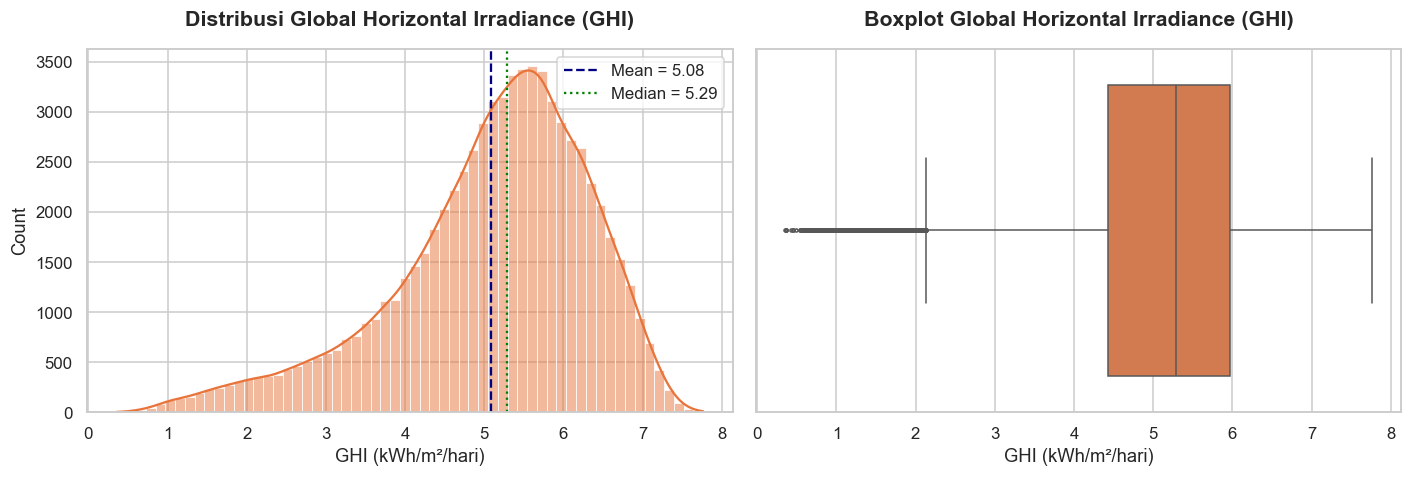

Skewness : -0.857
Kurtosis : 0.615
Minimum  : 0.355 kWh/m²/hari
Maksimum : 7.764 kWh/m²/hari


In [5]:
# Ambil data GHI tanpa missing value

ghi = df[TARGET].dropna()


# Visualisasi distribusi GHI menggunakan histogram, KDE, dan boxplot

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(
    ghi,
    bins=60,
    kde=True,
    color="#E8743B",
    ax=axes[0]
)

axes[0].axvline(
    ghi.mean(),
    color="navy",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {ghi.mean():.2f}"
)

axes[0].axvline(
    ghi.median(),
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {ghi.median():.2f}"
)

axes[0].set_title(
    "Distribusi Global Horizontal Irradiance (GHI)",
    fontsize=14,
    pad=15,
)
axes[0].set_xlabel(f"GHI ({UNITS['GHI']})")
axes[0].legend()

sns.boxplot(
    x=ghi,
    color="#E8743B",
    fliersize=2,
    ax=axes[1]
)

axes[1].set_title(
    "Boxplot Global Horizontal Irradiance (GHI)",
    fontsize=14,
    pad=15,
)
axes[1].set_xlabel(f"GHI ({UNITS['GHI']})")


# Tampilkan visualisasi dan statistik distribusi

plt.tight_layout()
plt.show()

print(f"Skewness : {ghi.skew():.3f}")
print(f"Kurtosis : {ghi.kurtosis():.3f}")
print(f"Minimum  : {ghi.min():.3f} {UNITS['GHI']}")
print(f"Maksimum : {ghi.max():.3f} {UNITS['GHI']}")

#### Analisis Distribusi Variabel Prediktor

Tahap ini bertujuan untuk menganalisis distribusi setiap variabel prediktor yang digunakan dalam penelitian. Visualisasi dilakukan menggunakan histogram dan kernel density estimation (KDE) untuk mengidentifikasi bentuk distribusi, tingkat kemencengan (skewness), serta karakteristik masing-masing fitur sebelum digunakan pada proses pemodelan.

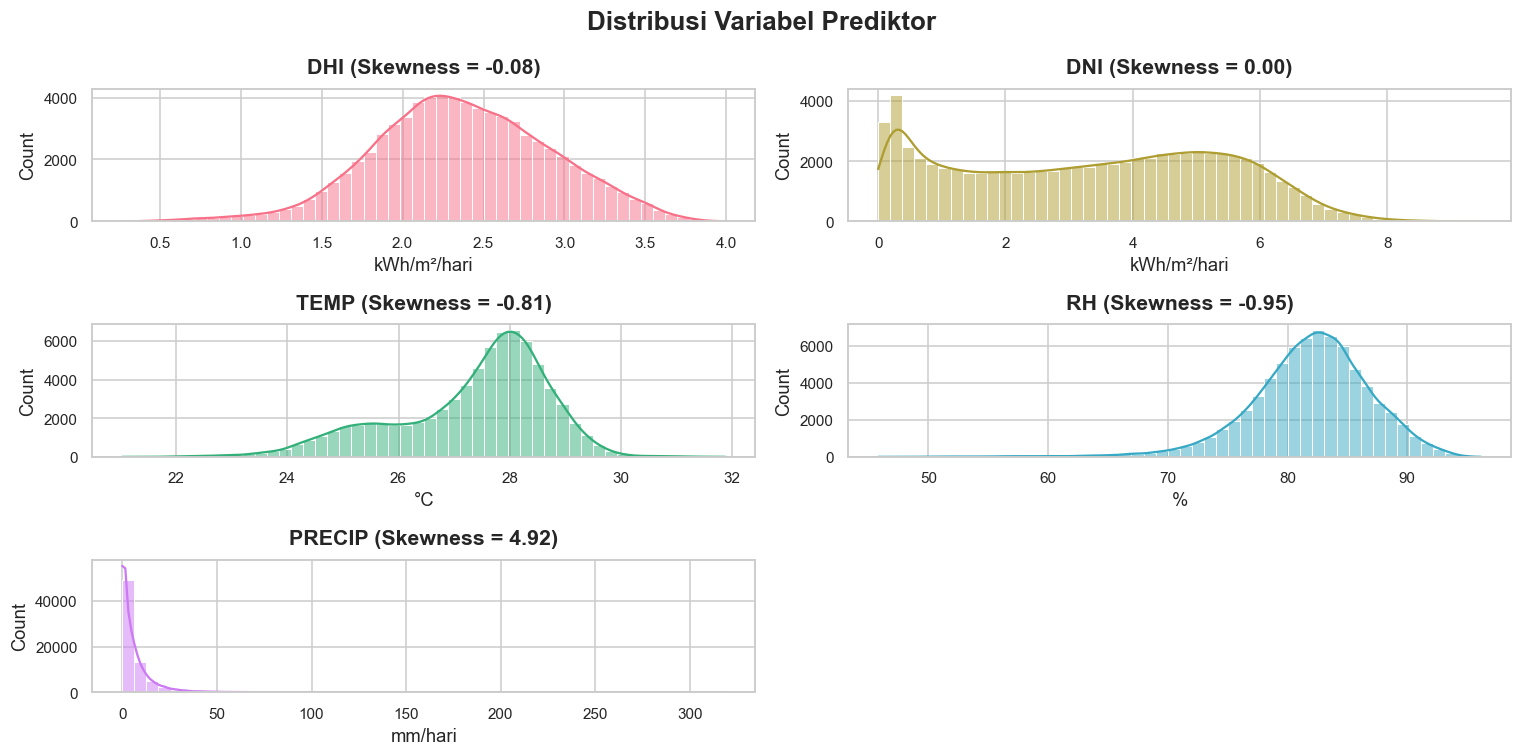

In [6]:
# Visualisasi distribusi seluruh fitur prediktor

fig, axes = plt.subplots(3, 2, figsize=(14, 7))

colors = sns.color_palette("husl", len(FEATURES))

for ax, feature, color in zip(axes.ravel(), FEATURES, colors):

    # Ambil data valid dan tampilkan distribusi
    value = df[feature].dropna()

    sns.histplot(
        value,
        bins=50,
        kde=True,
        color=color,
        ax=ax,
    )

    ax.set_title(
        f"{feature} (Skewness = {value.skew():.2f})",
        fontsize=14,
        fontweight="bold",
        pad=10,
    )

    ax.set_xlabel(UNITS[feature], fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)


# Rapikan subplot dan tampilkan visualisasi

axes.ravel()[-1].axis("off")

fig.suptitle(
    "Distribusi Variabel Prediktor",
    fontsize=17,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

#### Analisis Outlier

Tahap ini bertujuan untuk mengidentifikasi keberadaan nilai pencilan (outlier) pada setiap variabel numerik. Deteksi dilakukan menggunakan metode Interquartile Range (IQR) dengan aturan 1,5 × IQR untuk mengetahui batas bawah, batas atas, serta jumlah observasi yang berada di luar rentang tersebut.

In [7]:
# Fungsi untuk menghitung outlier menggunakan metode IQR

def calculate_iqr_outlier(series: pd.Series) -> dict:

    # Hitung batas IQR dan identifikasi data outlier
    series = series.dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    # Kembalikan ringkasan hasil deteksi outlier
    return {
        "lower_bound": round(lower_bound, 3),
        "upper_bound": round(upper_bound, 3),
        "n_outlier": int(outlier.sum()),
        "%_outlier": round(outlier.mean() * 100, 3),
    }


# Hitung dan tampilkan outlier untuk setiap variabel numerik

df_outlier = pd.DataFrame({
    column: calculate_iqr_outlier(df[column])
    for column in NUMERIC_COLUMNS
}).T

df_outlier

,lower_bound,upper_bound,n_outlier,%_outlier
GHI,2.126,8.273,2303.0,3.153
DHI,0.904,3.848,530.0,0.726
DNI,-4.074,10.568,0.0,0.000
TEMP,23.981,30.885,1300.0,1.780
RH,70.158,94.110,1617.0,2.214
PRECIP,-10.740,19.772,5268.0,7.212


#### Analisis Pola Temporal

Tahap ini bertujuan untuk menganalisis pola temporal pada variabel target, yaitu Global Horizontal Irradiance (GHI). Analisis dilakukan menggunakan deret waktu rata-rata harian dari seluruh lokasi untuk mengidentifikasi tren jangka panjang serta pola musiman yang muncul selama periode pengamatan.

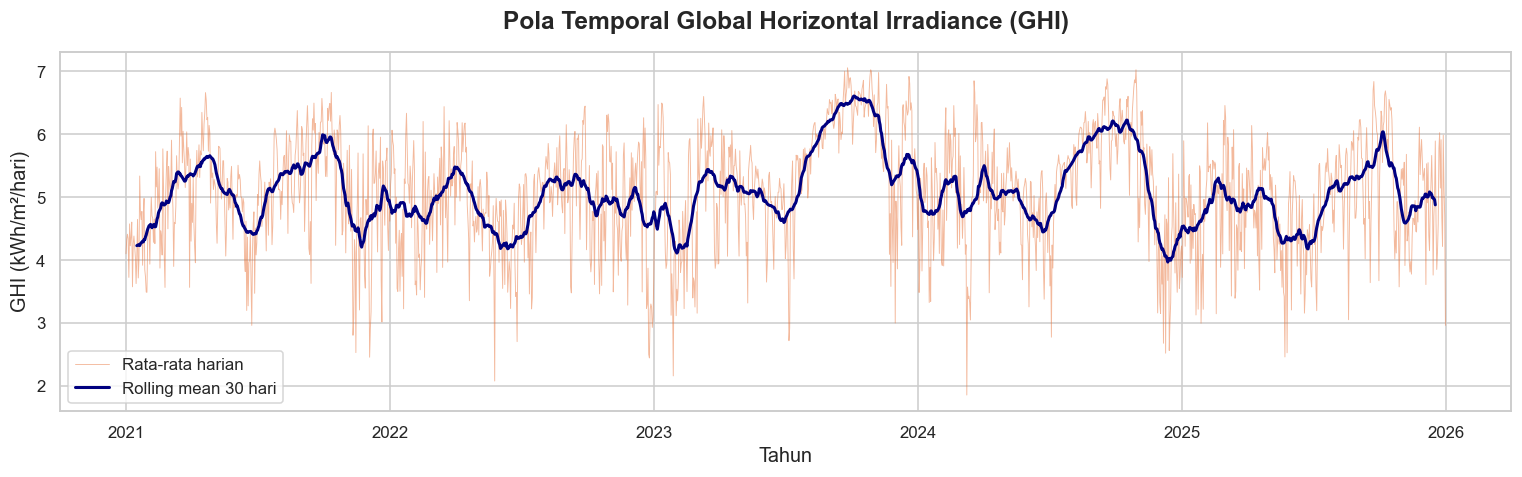

In [8]:
# Siapkan dataset dan informasi waktu untuk analisis temporal

df_time = df.copy()

df_time["year"] = df_time["date"].dt.year
df_time["month"] = df_time["date"].dt.month
df_time["day_of_year"] = df_time["date"].dt.dayofyear


# Hitung rata-rata harian seluruh lokasi

df_daily = (
    df_time.groupby("date")[NUMERIC_COLUMNS]
    .mean()
    .reset_index()
)


# Visualisasi pola temporal GHI dan rolling mean 30 hari

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(
    df_daily["date"],
    df_daily[TARGET],
    color="#E8743B",
    linewidth=0.6,
    alpha=0.5,
    label="Rata-rata harian"
)

ax.plot(
    df_daily["date"],
    df_daily[TARGET].rolling(30, center=True).mean(),
    color="navy",
    linewidth=2,
    label="Rolling mean 30 hari"
)


# Atur format sumbu dan label visualisasi

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title(
    "Pola Temporal Global Horizontal Irradiance (GHI)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Tahun", fontsize=13)
ax.set_ylabel(f"GHI ({UNITS['GHI']})", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
ax.legend(fontsize=11)


# Tampilkan visualisasi

plt.tight_layout()
plt.show()

#### Analisis Pola Musiman

Tahap ini bertujuan untuk menganalisis pola musiman setiap variabel utama berdasarkan rata-rata bulanan selama periode penelitian. Visualisasi dilakukan untuk mengidentifikasi perubahan musiman pada Global Horizontal Irradiance (GHI), curah hujan (PRECIP), dan kelembapan relatif (RH), sehingga hubungan antarvariabel dapat diamati secara deskriptif.

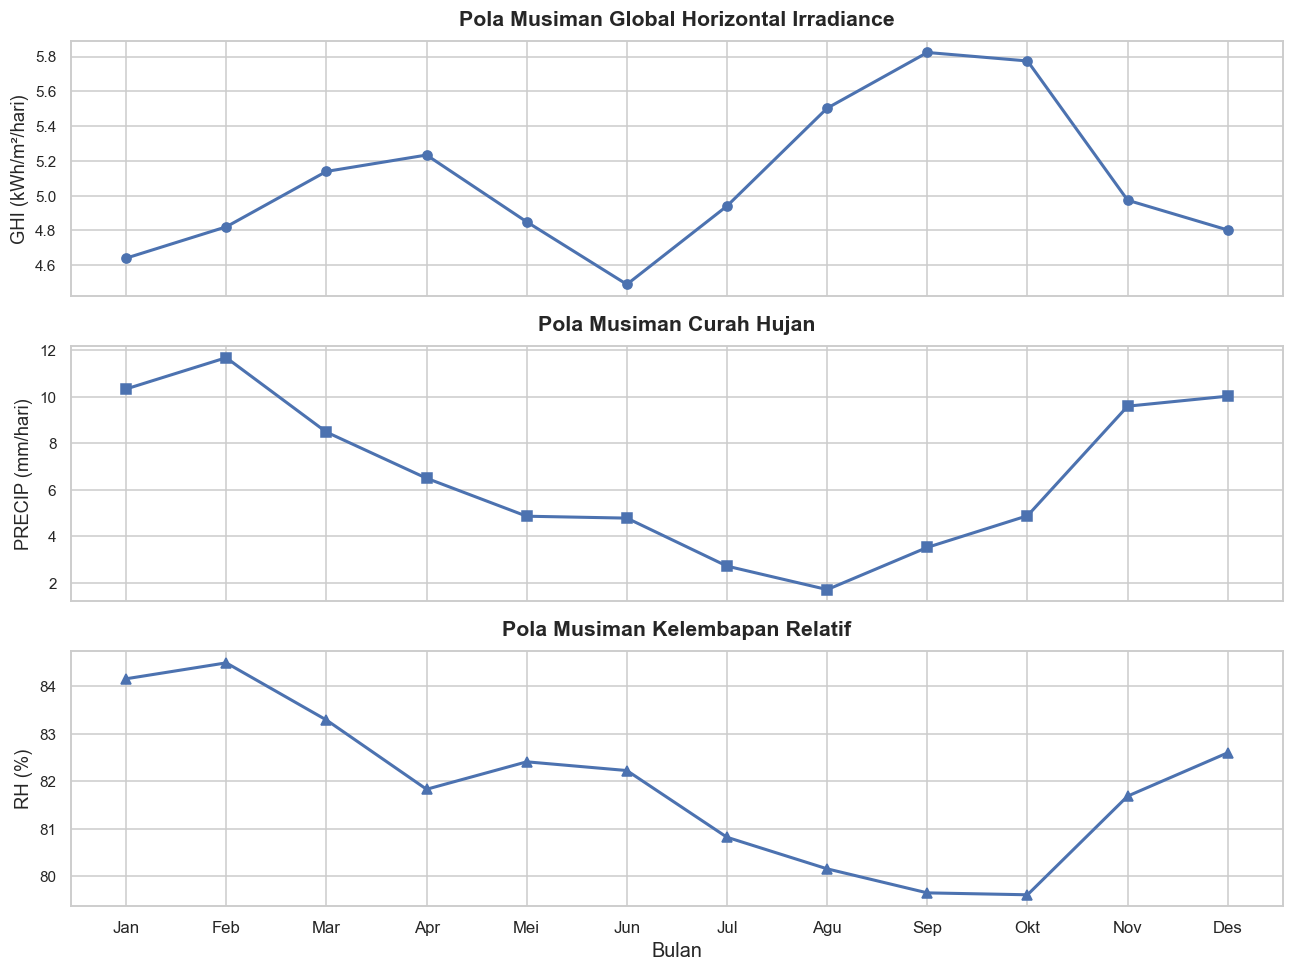

In [9]:
# Hitung rata-rata bulanan dan siapkan label nama bulan

monthly_mean = (
    df_time
    .groupby("month")[NUMERIC_COLUMNS]
    .mean()
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
    "Jul", "Agu", "Sep", "Okt", "Nov", "Des"
]


# Visualisasi pola musiman GHI, PRECIP, dan RH

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 9),
    sharex=True,
)

axes[0].plot(
    monthly_mean.index,
    monthly_mean["GHI"],
    marker="o",
    linewidth=2,
)
axes[0].set_title(
    "Pola Musiman Global Horizontal Irradiance",
    fontsize=14,
    fontweight="bold",
    pad=10,
)
axes[0].set_ylabel(f"GHI ({UNITS['GHI']})", fontsize=12)
axes[0].tick_params(axis="both", labelsize=10)
axes[0].grid(True)

axes[1].plot(
    monthly_mean.index,
    monthly_mean["PRECIP"],
    marker="s",
    linewidth=2,
)
axes[1].set_title(
    "Pola Musiman Curah Hujan",
    fontsize=14,
    fontweight="bold",
    pad=10,
)
axes[1].set_ylabel(f"PRECIP ({UNITS['PRECIP']})", fontsize=12)
axes[1].tick_params(axis="both", labelsize=10)
axes[1].grid(True)

axes[2].plot(
    monthly_mean.index,
    monthly_mean["RH"],
    marker="^",
    linewidth=2,
)
axes[2].set_title(
    "Pola Musiman Kelembapan Relatif",
    fontsize=14,
    fontweight="bold",
    pad=10,
)
axes[2].set_ylabel(f"RH ({UNITS['RH']})", fontsize=12)
axes[2].set_xlabel("Bulan", fontsize=13)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels, fontsize=11)
axes[2].tick_params(axis="y", labelsize=10)
axes[2].grid(True)


# Tampilkan visualisasi

plt.tight_layout()
plt.show()

#### Analisis Pola Spasial

Tahap ini bertujuan untuk menganalisis distribusi spasial nilai Global Horizontal Irradiance (GHI) pada seluruh titik grid penelitian. Analisis dilakukan menggunakan heatmap berdasarkan rata-rata GHI di setiap koordinat untuk mengidentifikasi variasi potensi radiasi surya antar lokasi.

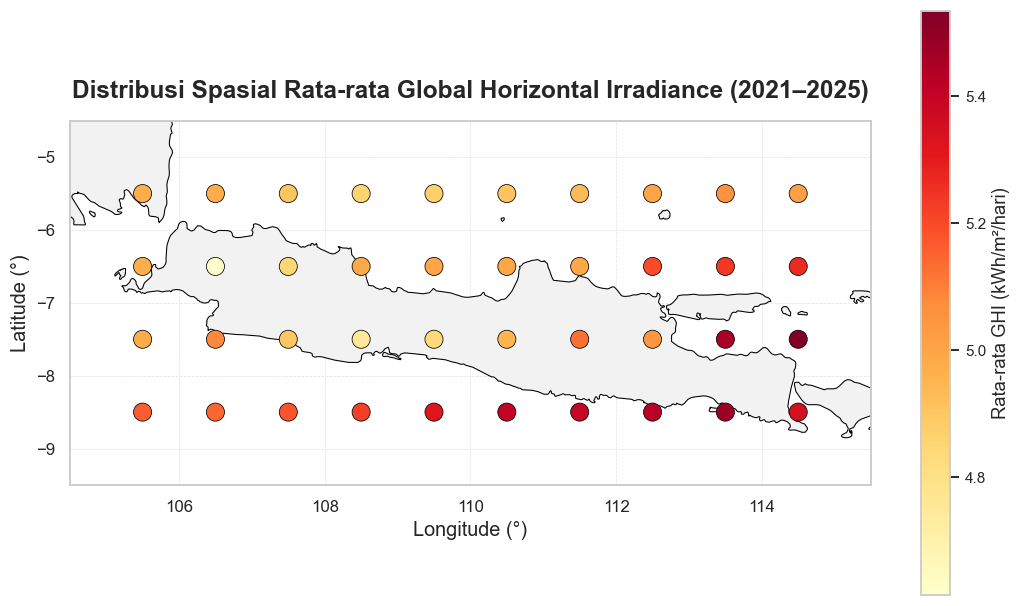

Jumlah lokasi : 40
Minimum GHI   : 4.61 kWh/m²/hari
Maksimum GHI  : 5.53 kWh/m²/hari
Rentang GHI   : 0.92 kWh/m²/hari


In [10]:
# Import library dan konfigurasi data geospasial

import geopandas as gpd
from shapely.geometry import box

SHAPEFILE = Path("../data/shapefile/ne_10m_admin_0_countries.shp")


# Hitung rata-rata GHI dan konversi koordinat menjadi GeoDataFrame

df_spatial = (
    df.groupby(["lat", "lon"])[TARGET]
    .mean()
    .reset_index()
)

gdf = gpd.GeoDataFrame(
    df_spatial,
    geometry=gpd.points_from_xy(
        df_spatial["lon"],
        df_spatial["lat"],
    ),
    crs="EPSG:4326",
)


# Muat shapefile dan batasi wilayah Indonesia pada area penelitian

world = gpd.read_file(SHAPEFILE)

indonesia = world[
    world["ADMIN"] == "Indonesia"
]

margin = 1.0

min_lon = df_spatial["lon"].min() - margin
max_lon = df_spatial["lon"].max() + margin
min_lat = df_spatial["lat"].min() - margin
max_lat = df_spatial["lat"].max() + margin

bbox = box(min_lon, min_lat, max_lon, max_lat)
indonesia_crop = indonesia.clip(bbox)


# Visualisasi distribusi spasial rata-rata GHI

fig, ax = plt.subplots(figsize=(10, 7))

indonesia_crop.plot(
    ax=ax,
    color="#F2F2F2",
    edgecolor="black",
    linewidth=0.7,
)

gdf.plot(
    ax=ax,
    column=TARGET,
    cmap="YlOrRd",
    markersize=140,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "label"  : f"Rata-rata GHI ({UNITS['GHI']})",
        "shrink" : 0.8,
    },
)


# Atur tampilan geografis dan elemen visualisasi

ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)
ax.set_aspect("equal")

ax.set_title(
    "Distribusi Spasial Rata-rata Global Horizontal Irradiance (2021–2025)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Longitude (°)", fontsize=13)
ax.set_ylabel("Latitude (°)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

colorbar = ax.get_figure().axes[-1]
colorbar.set_ylabel(
    f"Rata-rata GHI ({UNITS['GHI']})",
    fontsize=12,
)
colorbar.tick_params(labelsize=10)

ax.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.5,
)


# Tampilkan peta dan ringkasan statistik

plt.tight_layout()
plt.show()

print(f"Jumlah lokasi : {len(df_spatial)}")
print(f"Minimum GHI   : {df_spatial[TARGET].min():.2f} {UNITS['GHI']}")
print(f"Maksimum GHI  : {df_spatial[TARGET].max():.2f} {UNITS['GHI']}")
print(
    f"Rentang GHI   : "
    f"{df_spatial[TARGET].max() - df_spatial[TARGET].min():.2f} "
    f"{UNITS['GHI']}"
)

#### Analisis Korelasi Antarvariabel

Tahap ini bertujuan untuk mengevaluasi hubungan linear antara variabel target dan seluruh variabel prediktor menggunakan koefisien korelasi Pearson. Analisis ini membantu mengidentifikasi tingkat keterkaitan antarvariabel serta memberikan gambaran awal mengenai fitur-fitur yang berpotensi memberikan kontribusi terhadap proses pemodelan.

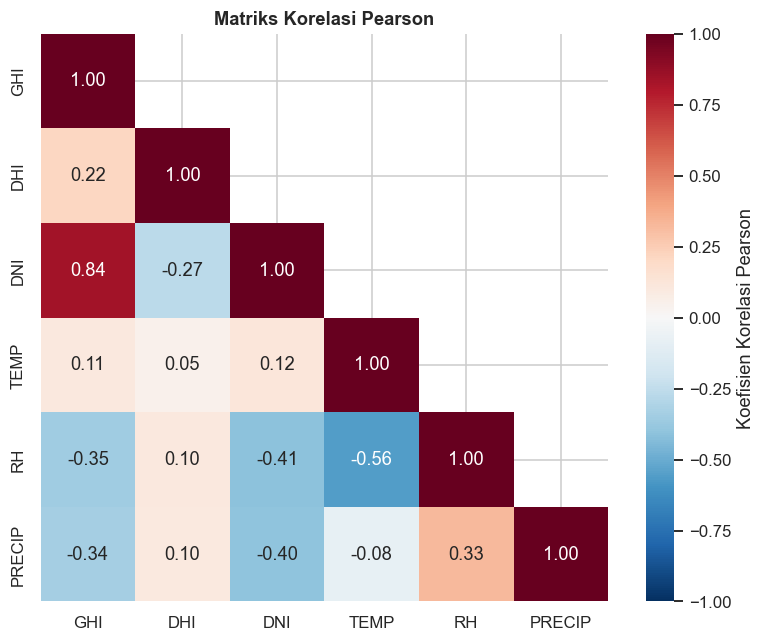

,Koefisien Korelasi Pearson,Kategori
DNI,0.839604,Sangat Kuat
RH,-0.351781,Lemah
PRECIP,-0.337137,Lemah
DHI,0.215269,Lemah
TEMP,0.108268,Sangat Lemah


In [11]:
# Hitung matriks korelasi Pearson

correlation_matrix = (
    df[NUMERIC_COLUMNS]
    .corr(method="pearson")
)

upper_triangle = np.triu(
    np.ones_like(correlation_matrix, dtype=bool),
    k=1,
)


# Visualisasi matriks korelasi

fig, ax = plt.subplots(figsize=(7.5, 6))

sns.heatmap(
    correlation_matrix,
    mask=upper_triangle,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={
        "label": "Koefisien Korelasi Pearson"
    },
    ax=ax,
)

ax.set_title("Matriks Korelasi Pearson")

plt.tight_layout()
plt.show()


# Hitung dan interpretasikan korelasi setiap fitur terhadap target GHI

correlation_target = (
    correlation_matrix[[TARGET]]
    .drop(index=TARGET)
    .rename(columns={TARGET: "Koefisien Korelasi Pearson"})
)


def interpret_correlation(r):
    r = abs(r)
    if r >= 0.80:
        return "Sangat Kuat"
    elif r >= 0.60:
        return "Kuat"
    elif r >= 0.40:
        return "Sedang"
    elif r >= 0.20:
        return "Lemah"
    else:
        return "Sangat Lemah"


correlation_target["Kategori"] = (
    correlation_target["Koefisien Korelasi Pearson"]
    .apply(interpret_correlation)
)


# Urutkan fitur berdasarkan kekuatan korelasi terhadap GHI

correlation_target = correlation_target.sort_values(
    by="Koefisien Korelasi Pearson",
    key=lambda s: s.abs(),
    ascending=False,
)

display(correlation_target)

#### Analisis Korelasi Fitur terhadap Variabel Target

Tahap ini bertujuan untuk mengevaluasi tingkat hubungan antara setiap variabel prediktor dengan variabel target (GHI). Analisis dilakukan menggunakan koefisien korelasi Pearson untuk mengukur hubungan linear dan Spearman untuk mengukur hubungan monotonik. Hasil analisis digunakan untuk mengidentifikasi fitur yang memiliki keterkaitan paling kuat dengan variabel target.

,Feature,Pearson,Spearman
1,DNI,0.840,0.867
3,RH,-0.351,-0.393
4,PRECIP,-0.337,-0.473
0,DHI,0.215,0.033
2,TEMP,0.108,0.163


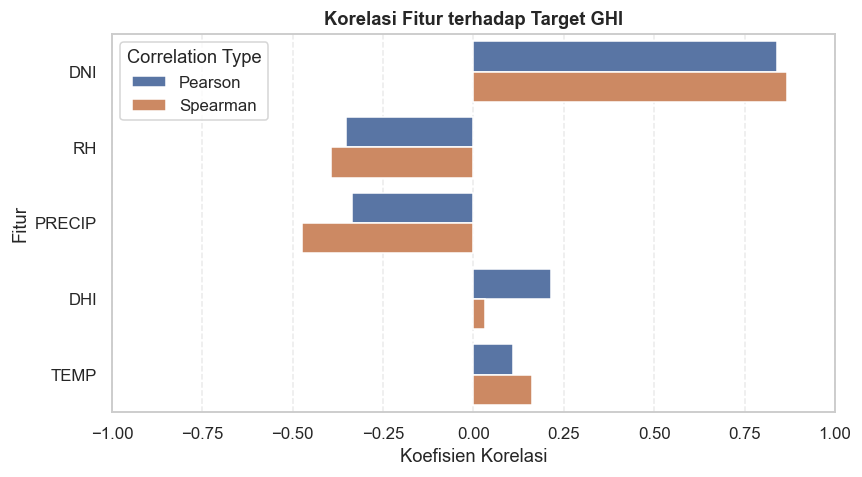

In [12]:
# Siapkan data tanpa missing value dan hitung korelasi fitur terhadap target

df_corr = df[NUMERIC_COLUMNS].dropna()

feature_correlation = []

for feature in FEATURES:

    pearson = df_corr[feature].corr(
        df_corr[TARGET],
        method="pearson",
    )

    spearman = df_corr[feature].corr(
        df_corr[TARGET],
        method="spearman",
    )

    feature_correlation.append({
        "Feature": feature,
        "Pearson": pearson,
        "Spearman": spearman,
    })


# Susun dan tampilkan hasil korelasi

df_feature_correlation = (
    pd.DataFrame(feature_correlation)
    .sort_values(
        by="Pearson",
        key=lambda s: s.abs(),
        ascending=False,
    )
)

display(df_feature_correlation.round(3))


# Ubah hasil ke format long untuk visualisasi

plot_data = df_feature_correlation.melt(
    id_vars="Feature",
    value_vars=["Pearson", "Spearman"],
    var_name="Correlation Type",
    value_name="Correlation",
)


# Visualisasi perbandingan korelasi Pearson dan Spearman

plt.figure(figsize=(8, 4.5))

sns.barplot(
    data=plot_data,
    x="Correlation",
    y="Feature",
    hue="Correlation Type",
)

plt.title("Korelasi Fitur terhadap Target GHI")
plt.xlabel("Koefisien Korelasi")
plt.ylabel("Fitur")
plt.xlim(-1, 1)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

#### Visualisasi Hubungan Fitur terhadap Variabel Target

Tahap ini bertujuan untuk memvisualisasikan hubungan antara setiap variabel prediktor dengan variabel target (GHI). Scatter plot digunakan untuk mengamati pola hubungan antarvariabel, sedangkan garis regresi linear ditambahkan untuk memberikan gambaran mengenai kecenderungan hubungan serta arah korelasi setiap fitur terhadap GHI.

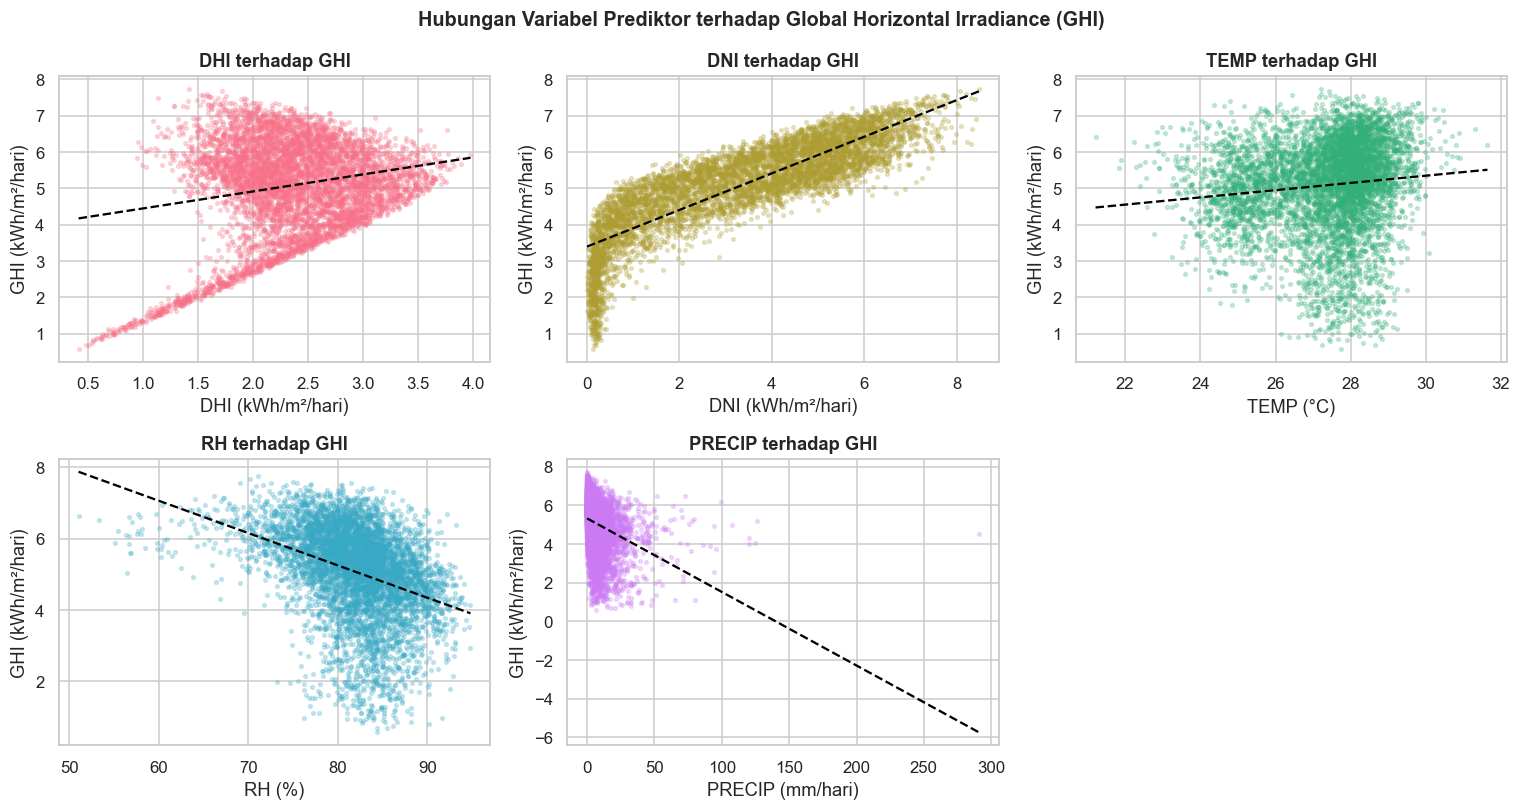

In [13]:
# Ambil sampel data untuk visualisasi hubungan fitur terhadap GHI

df_sample = (
    df[NUMERIC_COLUMNS]
    .dropna()
    .sample(
        n=min(6000, len(df)),
        random_state=42,
    )
)


# Visualisasi hubungan setiap fitur terhadap GHI

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))

for ax, feature, color in zip(
    axes.ravel(),
    FEATURES,
    colors,
):

    # Tampilkan scatter plot dan garis regresi linear
    ax.scatter(
        df_sample[feature],
        df_sample[TARGET],
        s=6,
        alpha=0.25,
        color=color,
    )

    slope, intercept = np.polyfit(
        df_sample[feature],
        df_sample[TARGET],
        1,
    )

    x = np.linspace(
        df_sample[feature].min(),
        df_sample[feature].max(),
        50,
    )

    ax.plot(
        x,
        slope * x + intercept,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    # Hitung korelasi Pearson dan atur label visualisasi
    r = df_sample[feature].corr(df_sample[TARGET])

    ax.set_title(f"{feature} terhadap GHI")
    ax.set_xlabel(f"{feature} ({UNITS[feature]})")
    ax.set_ylabel(f"GHI ({UNITS['GHI']})")


# Rapikan subplot dan tampilkan visualisasi

axes.ravel()[-1].axis("off")

fig.suptitle(
    "Hubungan Variabel Prediktor terhadap Global Horizontal Irradiance (GHI)",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

#### Evaluasi Kualitas Dataset

Tahap ini bertujuan untuk mengevaluasi kualitas akhir dataset yang akan digunakan pada proses pemodelan. Evaluasi meliputi pemeriksaan missing value pada setiap variabel, identifikasi waktu terjadinya missing value, serta perbandingan karakteristik data hasil interpolasi dan ekstrapolasi untuk memastikan proses harmonisasi spasial tidak menimbulkan perbedaan yang signifikan.

In [16]:
# Ringkas dan tampilkan missing value

df_missing = pd.DataFrame({
    "n_missing": df[NUMERIC_COLUMNS].isna().sum(),
    "%_missing": (
        df[NUMERIC_COLUMNS]
        .isna()
        .mean()
        * 100
    ).round(4),
})

display(df_missing)


# Identifikasi tanggal dengan missing value pada komponen irradiance

missing_date = (
    df.loc[
        df[["DHI", "DNI"]].isna().any(axis=1),
        "date",
    ]
    .dt.date
    .unique()
)

print(f"Tanggal dengan missing value pada DHI/DNI: {missing_date}")


# Evaluasi kelengkapan temporal pada setiap lokasi

df_temporal = (
    df.groupby("location_id")
    .agg(
        jumlah_hari=("date", "nunique"),
        tanggal_awal=("date", "min"),
        tanggal_akhir=("date", "max"),
    )
)

hari_expected = (
    pd.date_range(
        df["date"].min(),
        df["date"].max(),
        freq="D",
    )
    .size
)

print("\n=== Temporal Coverage ===")
print(f"Hari yang diharapkan : {hari_expected}")
print(
    f"Hari aktual per lokasi: "
    f"{df_temporal['jumlah_hari'].min()} - "
    f"{df_temporal['jumlah_hari'].max()}"
)
print(
    f"Panel seimbang       : "
    f"{df_temporal['jumlah_hari'].nunique() == 1}"
)


# Evaluasi cakupan spasial dan dampak proses ekstrapolasi

print("\n=== Spatial Harmonization ===")

print(
    f"Proporsi data hasil ekstrapolasi: "
    f"{df['meteo_clamped'].mean() * 100:.2f}%"
)

df_extrapolation = (
    df.groupby("meteo_clamped")[NUMERIC_COLUMNS]
    .mean()
    .round(3)
)

df_extrapolation.index = (
    df_extrapolation.index
    .map({
        False: "Interior",
        True: "Clamped",
    })
)

display(df_extrapolation)


# Periksa rentang nilai dan batas fisik variabel

df_range_check = pd.DataFrame({
    "minimum": df[NUMERIC_COLUMNS].min(),
    "maximum": df[NUMERIC_COLUMNS].max(),
})

display(df_range_check)

physical_check = pd.Series({
    "GHI >= 0": (df["GHI"].dropna() >= 0).all(),
    "DHI >= 0": (df["DHI"].dropna() >= 0).all(),
    "DNI >= 0": (df["DNI"].dropna() >= 0).all(),
    "RH berada pada 0-100%": df["RH"].dropna().between(0, 100).all(),
    "PRECIP >= 0": (df["PRECIP"].dropna() >= 0).all(),
})


# Tampilkan hasil validasi batas fisik

display(
    physical_check
    .rename("status")
    .map({
        True: "OK",
        False: "FAILED",
    })
)

,n_missing,%_missing
GHI,0,0.0000
DHI,40,0.0548
DNI,40,0.0548
TEMP,0,0.0000
RH,0,0.0000
PRECIP,0,0.0000


Tanggal dengan missing value pada DHI/DNI: [datetime.date(2025, 12, 31)]

=== Temporal Coverage ===
Hari yang diharapkan : 1826
Hari aktual per lokasi: 1826 - 1826
Panel seimbang       : True

=== Spatial Harmonization ===
Proporsi data hasil ekstrapolasi: 20.00%


,GHI,DHI,DNI,TEMP,RH,PRECIP
meteo_clamped,,,,,,
Interior,5.066,2.377,3.283,27.240,81.946,6.621
Clamped,5.157,2.353,3.513,27.712,81.707,6.300


,minimum,maximum
GHI,0.3547,7.7645
DHI,0.2681,3.9936
DNI,0.0000,9.4740
TEMP,21.0300,31.8800
RH,45.8000,96.1880
PRECIP,0.0000,318.6800


GHI >= 0                 OK
DHI >= 0                 OK
DNI >= 0                 OK
RH berada pada 0-100%    OK
PRECIP >= 0              OK
Name: status, dtype: str